# 72-hour SHARP training — Gray-Box project

**Bamidele Akinwumi · exploratory experiment · no AIA pixels required**

Train three compact GRU models and a matched logistic reference, preserve their checkpoints, and evaluate frozen raw scores across solar cycles. This notebook includes the executable model and training functions; it does not require the repository's Python modules.

The first local run found similar Brier scores for both models on Cycle 25, with slightly higher average precision for the GRU ensemble. These candidate-label results do not establish a significant improvement. Calibration, conformal sets and an operational decision policy are subsequent stages.

## Context and methods

- Inputs: 16 SHARP parameters at issue minus 288, 192 and 96 native minutes; physical UTC observation times are preserved.
- Outcome: candidate science-class M/X event start in `(issue, issue + 72 h]`, associated with the primary NOAA region. Unknown labels never become negatives.
- Model fitting uses 2010–2013; early stopping uses January–June 2014. Later Cycle-24 blocks are reserved for probability calibration, conformal calibration and policy development.
- Cycle 25 (2021–2025) is retrospective evaluation; 2026 through 17 August is supplementary. Previously inspected years are not untouched prospective confirmation.
- A 24-hour reporting delay is an explicit assumption. Earlier windows crossing each block's boundary are purged.
- Three short histories differ from the published seven-daily-state model. This is a new compact baseline, not its reproduction.

### Run locally or in Colab

Locally, use the `.venv-training` kernel and run all cells. In Colab, upload `gray_box_aligned_v1.zip` to `/content`, set `WORKSPACE = Path('/content')`, and run the optional dependency cell if required. The archive is approximately 46 MB; no AIA image download is needed. You may also point `DATASET_DIR` to an already extracted, verified package.

Every full run writes a new timestamped result directory. Existing results are preserved. The saved notebook includes actual local execution outputs; Colab execution is not claimed here.

## 1. Environment

In [1]:
# Set True only when the current kernel lacks the required libraries.
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
        'numpy==2.3.5', 'pandas==2.2.3', 'torch==2.8.0', 'matplotlib==3.10.7'])
    print('Restart the kernel after installation, set this flag to False, then run all cells.')

In [2]:
import contextlib
from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path
import random
import tempfile
import time
import zipfile

import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display, Markdown

print({'numpy': np.__version__, 'pandas': pd.__version__, 'torch': torch.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3', 'torch': '2.8.0'}


## 2. Paths and frozen experiment configuration

Change paths here. Keep the target and split definitions fixed when comparing models. Updating the configuration creates a different experiment.

In [3]:
# In Colab, set WORKSPACE = Path('/content'). Locally the repository is detected.
WORKSPACE = Path.cwd()
if WORKSPACE.name == 'notebooks':
    WORKSPACE = WORKSPACE.parent
DATASET_DIR = WORKSPACE / 'data/processed/training_snapshot_20261002/gray_box_aligned_v1'
DATASET_ARCHIVE = WORKSPACE / 'data/processed/gray_box_aligned_v1.zip'
if not DATASET_ARCHIVE.exists() and (WORKSPACE / 'gray_box_aligned_v1.zip').exists():
    DATASET_ARCHIVE = WORKSPACE / 'gray_box_aligned_v1.zip'
RUN_NAME = 'sharp72_notebook_v1_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR = WORKSPACE / 'outputs' / RUN_NAME
CONFIG = json.loads(r'''{
  "experiment": "sharp72_temporal_candidate_v1",
  "status": "exploratory_candidate_labels",
  "dataset_manifest_sha256": "7bb88614482cacd5fafb145d88345132a6cf97b25b8313dbefd90b08ac5b9d27",
  "horizon": 72,
  "scope": "primary",
  "reporting_delay_hours": 24,
  "reporting_delay_status": "assumed sensitivity parameter; historical delivery unverified",
  "blocks": [
    {
      "role": "train",
      "start": "2010-01-01",
      "end": "2014-01-01"
    },
    {
      "role": "model_validation",
      "start": "2014-01-01",
      "end": "2014-07-01"
    },
    {
      "role": "probability_calibration",
      "start": "2014-07-01",
      "end": "2015-01-01"
    },
    {
      "role": "conformal_calibration",
      "start": "2015-01-01",
      "end": "2015-07-01"
    },
    {
      "role": "policy_validation",
      "start": "2015-07-01",
      "end": "2020-01-01"
    },
    {
      "role": "retrospective_cycle25",
      "start": "2021-01-01",
      "end": "2026-01-01"
    },
    {
      "role": "supplementary_2026",
      "start": "2026-01-01",
      "end": "2027-01-01"
    }
  ],
  "model": "one_layer_GRU_last_hidden_linear",
  "hidden_size": 32,
  "head_dropout": 0.2,
  "seeds": [
    17,
    29,
    43
  ],
  "max_epochs": 30,
  "patience": 5,
  "batch_size": 256,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "gradient_clip": 1.0,
  "loss": "unweighted_binary_cross_entropy",
  "selection": "minimum model_validation log loss per seed; all seeds retained",
  "ensemble": "arithmetic_mean_of_all_three_seed_probabilities",
  "reference": "L2_logistic_same_training_cases_fixed_penalty_0.01",
  "evaluation_threshold": 0.5,
  "device": "cpu",
  "cpu_threads": 2
}''')
display(pd.DataFrame(CONFIG['blocks']))
print('Dataset:', DATASET_DIR)
print('New run:', OUTPUT_DIR)

,role,start,end
0,train,2010-01-01,2014-01-01
1,model_validation,2014-01-01,2014-07-01
2,probability_calibration,2014-07-01,2015-01-01
3,conformal_calibration,2015-01-01,2015-07-01
4,policy_validation,2015-07-01,2020-01-01
5,retrospective_cycle25,2021-01-01,2026-01-01
6,supplementary_2026,2026-01-01,2027-01-01


Dataset: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/data/processed/training_snapshot_20261002/gray_box_aligned_v1
New run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_notebook_v1_20261002T080801721986Z


## 3. Load and verify the data

The archive and manifest are pinned. A changed file stops execution. Blank histories remain unavailable; unknown outcomes are excluded from training and metric calculations. This cohort was assembled for matched modalities, so removing AIA does not make it a complete SHARP census.

In [4]:
if not DATASET_DIR.exists():
    if not DATASET_ARCHIVE.is_file():
        raise FileNotFoundError('Upload gray_box_aligned_v1.zip or set DATASET_DIR to its extracted folder.')
    with DATASET_ARCHIVE.open('rb') as stream:
        archive_hash = hashlib.file_digest(stream, 'sha256').hexdigest()
    assert archive_hash == '3bb0a7fc10d0192ed8bdabb4744079ac8ed7bcc8845d4bd21fefa45068b3df18', 'Archive changed'
    extraction_root = DATASET_DIR.parent
    extraction_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATASET_ARCHIVE) as archive:
        assert all(not Path(n).is_absolute() and '..' not in Path(n).parts for n in archive.namelist())
        archive.extractall(extraction_root)
print('Data package located; full checks run before fitting.')

Data package located; full checks run before fitting.


In [5]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()

def load_dataset(path, horizon=72, scope="primary", verify=True):
    root = Path(path)
    if horizon not in (48, 72) or scope not in ("primary", "patch"):
        raise ValueError("Choose horizon 48/72 and scope primary/patch")
    manifest = json.loads((root / "manifest.json").read_text())
    required = {"sharp.npy", "sharp_missing.npy", "input_index.csv.gz", "master_cases.csv.gz",
                f"y_{scope}_{horizon}h.npy", f"known_{scope}_{horizon}h.npy"}
    if not required.issubset(manifest["outputs"]):
        raise ValueError("Manifest does not pin every required model input")
    for name in required:
        if not (root / name).is_file():
            raise ValueError(f"Required dataset file missing: {name}")
    if verify:
        for name, item in manifest["outputs"].items():
            if not (root / name).is_file():
                raise ValueError(f"Required dataset file missing: {name}")
            actual = file_sha256(root / name)
            if actual != item["sha256"]:
                raise ValueError(f"Package checksum mismatch: {name}")
    sharp = np.load(root / "sharp.npy", mmap_mode="r", allow_pickle=False)
    missing = np.load(root / "sharp_missing.npy", mmap_mode="r", allow_pickle=False)
    y = np.load(root / f"y_{scope}_{horizon}h.npy", allow_pickle=False)
    known = np.load(root / f"known_{scope}_{horizon}h.npy", allow_pickle=False)
    index = pd.read_csv(root / "input_index.csv.gz")
    if tuple(manifest["sharp_shape"]) != sharp.shape or missing.shape != sharp.shape:
        raise ValueError("Tensor dimensions do not match the manifest")
    if sharp.ndim != 3 or sharp.shape[1:] != (len(manifest["history_lag_native_minutes"]), len(manifest["feature_order"])):
        raise ValueError("Feature/history dimensions differ from their declared order")
    if str(sharp.dtype) != manifest["sharp_dtype"] or not np.issubdtype(sharp.dtype, np.floating):
        raise ValueError("Unexpected SHARP numeric type")
    if missing.dtype != np.bool_ or not np.array_equal(missing, ~np.isfinite(sharp)):
        raise ValueError("Feature missingness mask differs from actual values")
    if len(index) != len(sharp) or index.forecast_case_id.isna().any() or index.forecast_case_id.duplicated().any() or not np.array_equal(index.tensor_row, np.arange(len(sharp))):
        raise ValueError("Case/tensor row alignment mismatch")
    if known.dtype != np.bool_ or y.shape != (len(sharp),) or not np.isin(y, [-1, 0, 1]).all() or not np.array_equal(known, y != -1):
        raise ValueError("Label/mask mismatch")
    return {"sharp": sharp, "missing": missing, "labels": y, "known": known,
            "index": index, "manifest": manifest}

def preflight_dataset(path, horizon=72, scope="primary", purpose="exploratory"):
    """Validate all target variants once; uncertainty remains explicit, not an error."""
    if purpose not in ("exploratory", "confirmatory"):
        raise ValueError("Unknown experiment purpose")
    root = Path(path)
    data = load_dataset(root, horizon, scope, verify=True)
    manifest, index = data["manifest"], data["index"]
    if purpose == "confirmatory" and not manifest["operational_training_ready"]:
        raise ValueError("This candidate package is exploratory; final label/availability clearance is not established")
    master = pd.read_csv(root / "master_cases.csv.gz", low_memory=False)
    if len(master) != manifest["case_count"] or master.forecast_case_id.isna().any() or master.forecast_case_id.duplicated().any():
        raise ValueError("Master-case keys/counts are inconsistent")
    if not master.inputs_available.eq(master.tensor_row.ge(0)).all():
        raise ValueError("Input availability differs from tensor pointers")
    matched = master.loc[master.tensor_row.ge(0)].sort_values("tensor_row")
    if not np.array_equal(matched.tensor_row, np.arange(len(index))) or not np.array_equal(matched.forecast_case_id, index.forecast_case_id):
        raise ValueError("Master-case and tensor-index mapping differ")
    for col in ("source_sample_id", "region_component_id"):
        if matched[col].isna().any() or not np.array_equal(matched[col], index[col]):
            raise ValueError(f"Master/index identity mismatch: {col}")
    issue = pd.to_datetime(index.issue_utc, utc=True, format="ISO8601")
    if issue.isna().any() or not np.array_equal(issue, pd.to_datetime(matched.issue_utc, utc=True, format="ISO8601")):
        raise ValueError("Missing or mismatched issue times")
    history = []
    for lag in manifest["history_lag_native_minutes"]:
        uri = f"history_uri_tminus{lag}"
        if index[uri].isna().any() or not index[uri].str.startswith("gs://").all() or not np.array_equal(index[uri], matched[uri]):
            raise ValueError(f"Missing or mismatched AIA reference: {uri}")
        times = pd.to_datetime(index[f"history_{lag}_UTC"], utc=True, format="ISO8601")
        if times.isna().any() or not times.lt(issue).all():
            raise ValueError("Missing or future predictor timestamp")
        if not np.array_equal(times, pd.to_datetime(matched[f"history_{lag}_UTC"], utc=True, format="ISO8601")):
            raise ValueError("Master/index history timestamp mismatch")
        history.append(times.astype("int64").to_numpy())
    if not (np.diff(np.column_stack(history), axis=1) > 0).all():
        raise ValueError("History slots are not chronologically ordered")
    targets = []
    for h in (48, 72):
        end = pd.to_datetime(matched[f"outcome_end_utc_{h}h"], utc=True, format="ISO8601").to_numpy()
        if pd.isna(end).any() or not (end > issue.to_numpy()).all():
            raise ValueError("Invalid outcome endpoint")
        for s in ("primary", "patch"):
            y = np.load(root / f"y_{s}_{h}h.npy", allow_pickle=False)
            known = np.load(root / f"known_{s}_{h}h.npy", allow_pickle=False)
            col = matched[f"candidate_{s}_label_{h}h"]
            if not col.dropna().isin([0, 1]).all() or not np.array_equal(col.fillna(-1).to_numpy(), y):
                raise ValueError(f"Master/array outcome mismatch: {h}/{s}")
            if known.dtype != np.bool_ or not np.array_equal(known, y != -1):
                raise ValueError(f"Unknown outcome mask mismatch: {h}/{s}")
            targets.append({"horizon": h, "scope": s, "known": int(known.sum()), "unknown": int((~known).sum())})
    data["master"] = master
    data["preflight"] = {"status": "passed", "purpose": purpose, "case_count": len(master),
        "tensor_count": len(index), "manifest_sha256": file_sha256(root / "manifest.json"),
        "checks": ["all package hashes", "master/tensor/label alignment", "four label masks", "feature masks",
                   "identity and AIA references", "past-only ordered histories", "outcome endpoints"],
        "targets": targets, "aia_remote_object_reads": 0,
        "remaining_limits": ["AIA pixel files are referenced, not downloaded or decoded in this preflight.",
            "Candidate zeros do not certify continuous observation coverage or historical delivery."]}
    return data

## 4. Temporal splits and training-only scaling

Signed `log1p` compression is followed by feature-wise scaling estimated from the training block only. No evaluation data are used for preprocessing or early stopping.

In [6]:
def write_json(path, value):
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")

def make_roles(index, master, known, supported, config):
    issue = pd.to_datetime(index.issue_utc, utc=True, format="ISO8601")
    end = pd.to_datetime(master[f"outcome_end_utc_{config['horizon']}h"], utc=True, format="ISO8601")
    mature = end + pd.Timedelta(hours=config["reporting_delay_hours"])
    roles = np.full(len(index), "outside_blocks", dtype=object)
    previous_end = None
    for block in config["blocks"]:
        start, stop = (pd.Timestamp(block[key], tz="UTC") for key in ("start", "end"))
        if start >= stop or (previous_end is not None and start < previous_end):
            raise ValueError("Overlapping or unordered time blocks")
        previous_end = stop
        selected = ((issue >= start) & (issue < stop)).to_numpy()
        # Purge incomplete outcome/reporting windows at every role boundary.
        roles[selected] = "purged_outcome_boundary"
        roles[selected & (mature <= stop).to_numpy()] = block["role"]
    roles[~known] = "unknown_label_excluded"
    roles[~supported] = "missing_input_excluded"
    return roles

def fit_transform(raw, train):
    if not train.any() or not np.isfinite(raw[train]).all():
        raise ValueError("Need finite training histories")
    logged = np.sign(raw[train]) * np.log1p(np.abs(raw[train]))
    mean = logged.mean(axis=(0, 1))
    std = logged.std(axis=(0, 1))
    std[std < 1e-12] = 1
    return {"mean": mean, "std": std}

def transform(raw, parameters):
    logged = np.sign(raw) * np.log1p(np.abs(raw))
    return np.asarray((logged - parameters["mean"]) / parameters["std"], dtype=np.float32)

## 5. GRU architecture and inference

One GRU layer with 32 hidden units, 0.2 head dropout and a linear binary output. All three random seeds are retained; no seed is selected using Cycle-25 results.

In [7]:
class SharpGRU(nn.Module):
    def __init__(self, features, hidden, dropout):
        super().__init__()
        self.gru = nn.GRU(features, hidden, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x):
        _, state = self.gru(x)
        return self.head(state[-1]).squeeze(-1)

def predict(model, x, batch_size=4096):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(x[i:i + batch_size]).sigmoid()
                          for i in range(0, len(x), batch_size)]).numpy()

display(SharpGRU(16, CONFIG['hidden_size'], CONFIG['head_dropout']))

SharpGRU(
  (gru): GRU(16, 32, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 6. Metrics and logistic reference

Brier skill uses the training prevalence as climatology. Average precision handles tied scores; AUC is undefined when only one outcome class is present. The logistic reference uses the same cases and transformed SHARP values.

In [8]:
def metrics(y, p, climatology, threshold=0.5):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    if not len(y):
        return {"cases": 0}
    if not np.isin(y, [0, 1]).all() or not np.isfinite(p).all():
        raise ValueError("Metrics require known binary targets and finite predictions")
    positive, negative = int(y.sum()), int((1-y).sum())
    brier = float(np.mean((y-p)**2))
    reference = float(np.mean((y-climatology)**2))
    clipped = np.clip(p, 1e-12, 1-1e-12)
    # Aggregate score ties before computing threshold-based AP and ROC area.
    order = np.argsort(-p, kind="stable")
    ends = np.r_[np.flatnonzero(np.diff(p[order]) != 0), len(y)-1]
    tp_curve = np.cumsum(y[order])[ends]
    fp_curve = (ends + 1) - tp_curve
    ap = float(np.sum(np.diff(np.r_[0, tp_curve]) / positive * tp_curve / (ends+1))) if positive else None
    auc = float(np.trapezoid(np.r_[0, tp_curve / positive], np.r_[0, fp_curve / negative])) if positive and negative else None
    alert = p >= threshold
    tp, fp = int((alert & (y == 1)).sum()), int((alert & (y == 0)).sum())
    fn, tn = positive-tp, negative-fp
    return {"cases": len(y), "positive": positive, "prevalence": positive/len(y),
            "brier": brier, "brier_skill_train_climatology": 1-brier/reference if reference else None,
            "log_loss": float(-np.mean(y*np.log(clipped)+(1-y)*np.log1p(-clipped))),
            "average_precision": ap, "roc_auc": auc, "threshold": threshold,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "tss": tp/positive-fp/negative if positive and negative else None}

def sigmoid(z):
    return np.exp(-np.logaddexp(0, -z))

def fit_logistic(x, y, penalty=0.01, max_iter=40):
    """Newton steps with backtracking for mean log loss + L2/2 (no intercept penalty)."""
    if x.ndim != 2 or y.shape != (len(x),) or max_iter < 1 or set(np.unique(y)) != {0, 1} or not np.isfinite(x).all() or penalty <= 0:
        raise ValueError("Need finite features, both binary classes and positive L2")
    design = np.column_stack([np.ones(len(x)), x])
    ridge = np.full(design.shape[1], penalty)
    ridge[0] = 0
    beta = np.zeros(design.shape[1])
    beta[0] = np.log(y.mean() / (1 - y.mean()))

    def loss(value):
        score = design @ value
        return np.mean(np.logaddexp(0, score) - y * score) + np.sum(ridge * value**2) / 2

    converged = False
    for iteration in range(max_iter):
        p = sigmoid(design @ beta)
        gradient = design.T @ (p - y) / len(y) + ridge * beta
        if np.max(np.abs(gradient)) < 1e-7:
            converged = True
            break
        hessian = (design.T * (p * (1 - p))) @ design / len(y) + np.diag(ridge)
        step = np.linalg.solve(hessian, gradient)
        previous = loss(beta)
        scale = 1.0
        while scale >= 2**-20 and loss(beta - scale * step) > previous - 1e-4 * scale * (gradient @ step):
            scale *= 0.5
        if scale < 2**-20:
            raise ValueError("Optimizer line search failed")
        beta -= scale * step
    if not converged:
        p = sigmoid(design @ beta)
        converged = np.max(np.abs(design.T @ (p - y) / len(y) + ridge * beta)) < 1e-7
    return beta, {"iterations": iteration + 1, "converged": bool(converged), "penalized_train_loss": float(loss(beta))}

## 7. Train each seed and save its best checkpoint

Use natural class prevalence and unweighted binary cross-entropy. Select the epoch with minimum earlier validation log loss; stop after five epochs without improvement. The saved transform and checkpoints must reproduce every supported prediction.

In [9]:
def train_seed(x, y, roles, config, seed, output):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = SharpGRU(x.shape[2], config["hidden_size"], config["head_dropout"])
    train, val = np.flatnonzero(roles == "train"), np.flatnonzero(roles == "model_validation")
    prior = float(y[train].mean())
    with torch.no_grad():
        model.head[-1].bias.fill_(np.log(prior/(1-prior)))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    loss_fn = nn.BCEWithLogitsLoss()
    targets = torch.from_numpy(y.astype(np.float32))
    best, best_epoch, stale, history = float("inf"), 0, 0, []
    checkpoint = output / f"seed_{seed}.pt"
    for epoch in range(1, config["max_epochs"]+1):
        started = time.monotonic()
        model.train()
        order = train[torch.randperm(len(train)).numpy()]
        total = 0.0
        for start in range(0, len(order), config["batch_size"]):
            indices = order[start:start+config["batch_size"]]
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(x[indices]), targets[indices])
            if not torch.isfinite(loss):
                raise ValueError("Nonfinite training loss")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
            optimizer.step()
            total += loss.item()*len(indices)
        p = predict(model, x[val])
        val_loss = metrics(y[val], p, prior)["log_loss"]
        history.append({"seed": seed, "epoch": epoch, "train_loss": total/len(train),
                        "validation_log_loss": val_loss, "seconds": time.monotonic()-started})
        if val_loss < best:
            best, best_epoch, stale = val_loss, epoch, 0
            torch.save(model.state_dict(), checkpoint)
        else:
            stale += 1
        pd.DataFrame(history).to_csv(output / f"seed_{seed}_history.csv", index=False)
        print(json.dumps({"seed": seed, "epoch": epoch, "validation_log_loss": round(val_loss, 6),
                          "best_epoch": best_epoch, "seconds": round(history[-1]["seconds"], 2)}), flush=True)
        if stale >= config["patience"]:
            break
    model.load_state_dict(torch.load(checkpoint, weights_only=True, map_location="cpu"))
    return model, {"seed": seed, "epochs": epoch, "best_epoch": best_epoch, "best_validation_log_loss": best}

## 8. Execute the complete training run

This cell trains the GRUs and logistic reference, then scores the reserved and evaluation cases. It does not fit calibrators or policies. Detailed epoch logs are written to a file; the notebook displays compact results below.

In [10]:
def run(dataset, config_path, output):
    if output.exists():
        raise ValueError("Output exists; choose a new run path. Existing experiments are immutable")
    config = json.loads(config_path.read_text())
    if config["device"] != "cpu":
        raise ValueError("This bounded local runner supports CPU only")
    if file_sha256(dataset / "manifest.json") != config["dataset_manifest_sha256"]:
        raise ValueError("Data version differs from the frozen experiment")
    torch.set_num_threads(config["cpu_threads"])
    torch.use_deterministic_algorithms(True)
    data = preflight_dataset(dataset, config["horizon"], config["scope"])
    index, raw, y, known = data["index"], data["sharp"], data["labels"], data["known"]
    master = data["master"].set_index("forecast_case_id").loc[index.forecast_case_id].reset_index()
    supported = np.isfinite(raw).all(axis=(1, 2))
    roles = make_roles(index, master, known, supported, config)
    for role in ("train", "model_validation"):
        if set(np.unique(y[roles == role])) != {0, 1}:
            raise ValueError(f"Both classes required in {role}")
    output.parent.mkdir(parents=True, exist_ok=True)
    staging = Path(tempfile.mkdtemp(prefix=output.name + ".incomplete-", dir=output.parent))
    contract = {"config": config, "config_sha256": file_sha256(config_path),
                "executed_cells_sha256": hashlib.sha256("\n\n".join(get_ipython().history_manager.input_hist_raw).encode()).hexdigest(),
                "versions": {"numpy": np.__version__, "pandas": pd.__version__, "torch": torch.__version__},
                "started_utc": datetime.now(timezone.utc).isoformat()}
    write_json(staging / "run_contract.json", contract)
    (staging / "executed_training_cells.py").write_text("\n\n".join(get_ipython().history_manager.input_hist_raw))
    try:
        plan = index[["forecast_case_id", "issue_utc", "region_component_id", "tensor_row"]].copy()
        plan["role"], plan["label"], plan["label_known"] = roles, y, known
        plan.to_csv(staging / "split_manifest.csv.gz", index=False, compression={"method": "gzip", "mtime": 0})
        role_support = []
        for role in sorted(set(roles)):
            mask = roles == role
            role_support.append({"role": role, "cases": int(mask.sum()), "positive": int((y[mask] == 1).sum()),
                                 "region_components": int(index.loc[mask, "region_component_id"].nunique())})
        print(json.dumps({"status": "training_started", "output_staging": str(staging), "roles": role_support}), flush=True)
        train = roles == "train"
        parameters = fit_transform(raw, train)
        np.savez(staging / "transform.npz", **parameters)
        # Unsupported rows are never fed into the model or scored.
        normalized = np.zeros(raw.shape, dtype=np.float32)
        normalized[supported] = transform(raw[supported], parameters)
        x = torch.from_numpy(normalized)
        prior = float(y[train].mean())
        seeds = []
        probabilities = []
        for seed in config["seeds"]:
            model, record = train_seed(x, y, roles, config, seed, staging)
            p = np.full(len(y), np.nan)
            p[supported] = predict(model, x[supported])
            replay = SharpGRU(raw.shape[2], config["hidden_size"], config["head_dropout"])
            replay.load_state_dict(torch.load(staging / f"seed_{seed}.pt", weights_only=True, map_location="cpu"))
            with np.load(staging / "transform.npz", allow_pickle=False) as saved:
                x_replay = torch.from_numpy(transform(raw[supported], saved))
            if not np.array_equal(p[supported], predict(replay, x_replay)):
                raise ValueError("Saved checkpoint/transform did not reproduce predictions")
            plan[f"probability_seed_{seed}"] = p
            probabilities.append(p)
            seeds.append(record)
        plan["probability_gru_mean"] = np.mean(probabilities, axis=0)
        # A fair interpretable reference uses exactly the same fitting population.
        flat = normalized.reshape(len(raw), -1).astype(float)
        beta, optimizer = fit_logistic(flat[train], y[train].astype(float))
        if not optimizer["converged"]:
            raise ValueError("Matched logistic reference failed to converge")
        np.savez(staging / "logistic_reference.npz", beta=beta, **parameters)
        plan["probability_logistic"] = sigmoid(beta[0] + flat @ beta[1:])
        plan.loc[~supported, "probability_logistic"] = np.nan
        rows = []
        # Calibration and policy labels remain reserved: no fitting or performance
        # inspection on those blocks during this backbone-training stage.
        for role in ("train", "model_validation", "retrospective_cycle25", "supplementary_2026"):
            selected = roles == role
            for column in ("probability_gru_mean", "probability_logistic"):
                rows.append({"role": role, "model": column, **metrics(y[selected], plan.loc[selected, column].to_numpy(), prior, config["evaluation_threshold"])})
        plan.to_csv(staging / "predictions.csv.gz", index=False, compression={"method": "gzip", "mtime": 0})
        population = data["master"][["forecast_case_id", "issue_utc", "inputs_available"]].merge(
            plan.drop(columns=["issue_utc", "tensor_row"]), on="forecast_case_id", how="left", validate="one_to_one")
        population["forecast_status"] = np.where(population.probability_gru_mean.notna(), "scored_exploratory", "no_supported_sharp_input")
        population.to_csv(staging / "population_predictions.csv.gz", index=False, compression={"method": "gzip", "mtime": 0})
        region_sets = {block["role"]: set(index.loc[roles == block["role"], "region_component_id"]) for block in config["blocks"]}
        overlap = {f"{a}|{b}": len(region_sets[a] & region_sets[b]) for i, a in enumerate(region_sets) for b in list(region_sets)[i+1:]}
        summary = {"status": "completed_exploratory_training", "completed_utc": datetime.now(timezone.utc).isoformat(),
                   "experiment": config["experiment"], "horizon": config["horizon"], "scope": config["scope"],
                   "roles": role_support, "seeds": seeds, "saved_model_replay": "identical_all_supported_cases_each_seed",
                   "metrics": rows, "train_climatology": prior, "region_overlap_by_role": overlap,
                   "population_rows": len(population), "unscored_rows": int(population.probability_gru_mean.isna().sum()),
                   "limitations": ["Candidate labels and provisional zeros; not confirmatory results.",
                       "Chronological roles with outcome/reporting purge, not an AR-disjoint or event-disjoint evaluation.",
                       "Prior Cycle-25 inspection makes evaluation retrospective; 2026 is supplementary.",
                       "Three short histories are not the published seven-daily-state ASR input contract.",
                       "Probabilities are uncalibrated; calibration/conformal/policy blocks are reserved for later stages.",
                       "Ensemble spread is seed disagreement, not a calibrated confidence interval.",
                       "Matched cohort selection and unassembled histories limit SHARP-only population claims."],
                   "output_sha256": {p.name: file_sha256(p) for p in staging.iterdir()}}
        write_json(staging / "summary.json", summary)
        if output.exists():
            raise ValueError("Output appeared during training; refusing replacement")
        staging.rename(output)
        print(json.dumps({"status": summary["status"], "output": str(output), "seeds": seeds}), flush=True)
    except Exception as exc:
        write_json(staging / "failure.json", {"error": str(exc), "incomplete_run": True})
        raise

In [11]:
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)
config_path = OUTPUT_DIR.parent / (RUN_NAME + '_config.json')
write_json(config_path, CONFIG)
log_path = OUTPUT_DIR.parent / (RUN_NAME + '.log')
with log_path.open('w') as log_stream, contextlib.redirect_stdout(log_stream):
    run(DATASET_DIR, config_path, OUTPUT_DIR)
summary = json.loads((OUTPUT_DIR / 'summary.json').read_text())
print(summary['status'])
print('Saved models, transform, split and predictions:', OUTPUT_DIR)
display(pd.DataFrame(summary['seeds']).round(6))

completed_exploratory_training
Saved models, transform, split and predictions: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_notebook_v1_20261002T080801721986Z


,seed,epochs,best_epoch,best_validation_log_loss
0,17,7,2,0.229605
1,29,9,4,0.229086
2,43,7,2,0.225659


## 9. Results and learning curves

These are uncalibrated, exploratory results. The calibration and policy blocks retain their labels for later stages; their performance is not inspected here.

In [12]:
support = pd.DataFrame(summary['roles'])
display(support)
results = pd.DataFrame(summary['metrics'])
evaluation = results[results.role.isin(['retrospective_cycle25', 'supplementary_2026'])].copy()
readable = evaluation[['role', 'model', 'cases', 'positive', 'brier',
                       'average_precision', 'roc_auc', 'brier_skill_train_climatology']].copy()
readable['role'] = readable['role'].replace({'retrospective_cycle25': 'Cycle 25: 2021–25', 'supplementary_2026': '2026: supplementary'})
readable['model'] = readable['model'].replace({'probability_gru_mean': 'GRU ensemble', 'probability_logistic': 'Logistic'})
readable = readable.rename(columns={'role': 'Period', 'model': 'Model', 'cases': 'Cases', 'positive': 'Positive windows',
    'brier': 'Brier', 'average_precision': 'AP', 'roc_auc': 'ROC AUC', 'brier_skill_train_climatology': 'Brier skill'})
display(readable.reset_index(drop=True).round(6))

,role,cases,positive,region_components
0,conformal_calibration,4168,384,95
1,model_validation,3905,416,99
2,policy_validation,13142,422,313
3,probability_calibration,2831,184,69
4,purged_outcome_boundary,375,47,16
5,retrospective_cycle25,35846,3860,943
6,supplementary_2026,11118,992,128
7,train,25586,1476,629
8,unknown_label_excluded,16462,0,664


,Period,Model,Cases,Positive windows,Brier,AP,ROC AUC,Brier skill
0,Cycle 25: 2021–25,GRU ensemble,35846,3860,0.077365,0.439603,0.848182,0.215263
1,Cycle 25: 2021–25,Logistic,35846,3860,0.077341,0.429880,0.846788,0.215504
2,2026: supplementary,GRU ensemble,11118,992,0.069099,0.396216,0.785834,0.159970
3,2026: supplementary,Logistic,11118,992,0.069042,0.395172,0.783862,0.160668


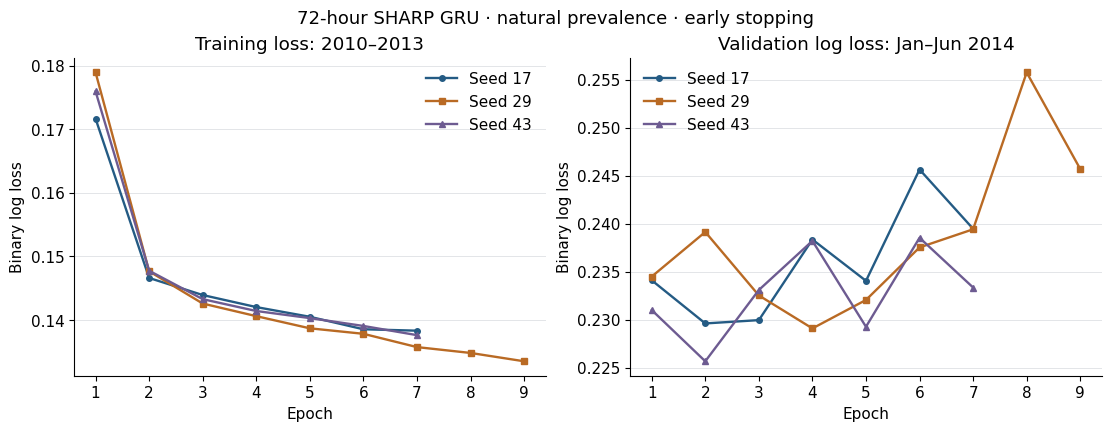

In [13]:
os.environ.setdefault('MPLCONFIGDIR', str(WORKSPACE / 'outputs' / '.matplotlib'))
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
colors = {17: '#245B84', 29: '#B96A24', 43: '#6D5B91'}
markers = {17: 'o', 29: 's', 43: '^'}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for seed in CONFIG['seeds']:
    history = pd.read_csv(OUTPUT_DIR / f'seed_{seed}_history.csv')
    for axis, column in zip(axes, ['train_loss', 'validation_log_loss']):
        axis.plot(history.epoch, history[column], marker=markers[seed], markersize=4,
                  color=colors[seed], label=f'Seed {seed}', linewidth=1.7)
for axis, title in zip(axes, ['Training loss: 2010–2013', 'Validation log loss: Jan–Jun 2014']):
    axis.set(title=title, xlabel='Epoch', ylabel='Binary log loss')
    axis.grid(axis='y', color='#E3E5E8', linewidth=0.7)
    axis.legend(frameon=False)
fig.suptitle('72-hour SHARP GRU · natural prevalence · early stopping', fontsize=13)
fig.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Verify saved outputs and interpret cautiously

In [14]:
for name, expected in summary['output_sha256'].items():
    assert file_sha256(OUTPUT_DIR / name) == expected, f'Changed output: {name}'
assert summary['saved_model_replay'] == 'identical_all_supported_cases_each_seed'
cycle25 = evaluation[evaluation.role == 'retrospective_cycle25'].set_index('model')
gru = cycle25.loc['probability_gru_mean']
logistic = cycle25.loc['probability_logistic']
display(Markdown(
    f"**Executed:** three GRU seeds and the matched logistic reference. "
    f"Cycle-25 Brier: GRU **{gru.brier:.6f}**, logistic **{logistic.brier:.6f}**; "
    f"average precision: **{gru.average_precision:.4f}** and **{logistic.average_precision:.4f}**, respectively. "
    "Small descriptive differences are not evidence of statistical significance."
))
print('All saved output hashes verified; checkpoint replay identical.')
print('Full population:', summary['population_rows'], '| Unscored missing-input cases:', summary['unscored_rows'])
display(Markdown('### Remaining limits\n' + '\n'.join('- ' + item for item in summary['limitations'])))

**Executed:** three GRU seeds and the matched logistic reference. Cycle-25 Brier: GRU **0.077365**, logistic **0.077341**; average precision: **0.4396** and **0.4299**, respectively. Small descriptive differences are not evidence of statistical significance.

All saved output hashes verified; checkpoint replay identical.
Full population: 153366 | Unscored missing-input cases: 39933


### Remaining limits
- Candidate labels and provisional zeros; not confirmatory results.
- Chronological roles with outcome/reporting purge, not an AR-disjoint or event-disjoint evaluation.
- Prior Cycle-25 inspection makes evaluation retrospective; 2026 is supplementary.
- Three short histories are not the published seven-daily-state ASR input contract.
- Probabilities are uncalibrated; calibration/conformal/policy blocks are reserved for later stages.
- Ensemble spread is seed disagreement, not a calibrated confidence interval.
- Matched cohort selection and unassembled histories limit SHARP-only population claims.

## Next steps

Fit and compare probability calibration on the reserved earlier block, then develop conformal classification and the decision policy using their separate blocks. Keep this run frozen. Do not choose methods from the already inspected Cycle-25 scores.

**Data source:** `gray_box_aligned_v1.zip`, archive SHA-256 `3bb0a7fc10d0192ed8bdabb4744079ac8ed7bcc8845d4bd21fefa45068b3df18`; manifest SHA-256 is recorded in `CONFIG`. GOES provides event outcomes here, not continuous XRS predictors. Per-run contracts retain the executed notebook code, configuration, runtime versions and output hashes. Candidate labels and historical availability remain scientifically provisional.